> Federated Learning workflow with Autonomous client and model aggregation methos selection

### 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import datasets, transforms
import random
import copy
import time
import warnings
from collections import defaultdict, deque
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional
from tqdm import tqdm
import logging

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

/home/MacNight_nj/.local/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Using device: cpu


### 2. Model building

In [2]:
class LightweightCNN(nn.Module):
    """Lightweight CNN optimized for IoT resource-constrained devices"""

    def __init__(self, num_classes=10, in_channels=1):
        super(LightweightCNN, self).__init__()

        # Convolutional layers with depthwise separable convolution
        self.conv1 = nn.Conv2d(in_channels, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)

        # Pooling and dropout
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.3)

        # Fully connected layers
        self.fc1 = nn.Linear(64 * 3 * 3, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        # Feature extraction
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        # Flatten and classify
        x = x.view(-1, 64 * 3 * 3)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

In [3]:
def local_train(model, loader, epochs=1, lr=0.01, device="cpu"):
    """Fixed training with proper gradient quality measurement"""
    model.train()
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    total_loss = 0
    gradient_norms = []

    for epoch in range(epochs):
        for batch_idx, (data, targets) in enumerate(
            tqdm(loader, desc="Training", leave=False)
        ):
            data, targets = data.to(device), targets.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, targets)
            loss.backward()

            # Calculate gradient norm for quality metric
            total_norm = 0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            total_norm = total_norm ** (1. / 2)
            gradient_norms.append(total_norm)

            optimizer.step()
            total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    gradient_quality = np.mean(gradient_norms) if gradient_norms else 0.0
    training_time = np.random.uniform(0.5, 2.0) * epochs

    return training_time, model.state_dict(), gradient_quality, avg_loss

def evaluate_model(model: nn.Module, test_loader: DataLoader) -> Dict[str, float]:
    """Comprehensive model evaluation"""
    model.eval()
    correct = 0
    total = 0
    all_predictions = []
    all_labels = []
    total_loss = 0.0
    criterion = nn.CrossEntropyLoss()
    
    with torch.no_grad():
        for data, labels in test_loader:
            data, labels = data.to(device), labels.to(device)
            outputs = model(data)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    accuracy = correct / total
    avg_loss = total_loss / len(test_loader)
    
    # Calculate precision, recall, F1 for each class then average
    from sklearn.metrics import precision_recall_fscore_support
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_predictions, average='weighted', zero_division=0
    )
    
    return {
        'accuracy': accuracy,
        'loss': avg_loss,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    }


### 3. Dataset preparation

In [4]:
batch_size = 64

train_dataset = datasets.FashionMNIST(root="data/", download=True, train=True, transform=transforms.ToTensor())

train_loader = DataLoader(dataset=train_dataset, shuffle=True)

test_dataset = datasets.FashionMNIST(root="data/", download=True, train=False, transform=transforms.ToTensor())

test_loader = DataLoader(dataset=test_dataset, shuffle=True)


#### 3.1. Data Distribution for Federated Learning

In [5]:
def create_non_iid_dirichlet_split(dataset, num_clients, alpha=0.5, min_samples=10):
    """Create non-IID data distribution using Dirichlet distribution"""
    
    labels = np.array([dataset[i][1] for i in range(len(dataset))])
    num_classes = len(np.unique(labels))
    
    # Group indices by class
    class_indices = [np.where(labels == i)[0] for i in range(num_classes)]
    
    # Generate Dirichlet distribution for each client
    client_distributions = np.random.dirichlet([alpha] * num_classes, num_clients)
    
    client_datasets = {}
    client_stats = {}
    
    for client_id in range(num_clients):
        client_indices = []
        class_counts = {}
        
        # Calculate samples per class for this client
        total_samples = len(dataset) // num_clients
        
        for class_id in range(num_classes):
            n_samples = max(1, int(client_distributions[client_id][class_id] * total_samples))
            
            if len(class_indices[class_id]) > 0:
                # Sample from available indices
                available_indices = class_indices[class_id]
                selected_count = min(n_samples, len(available_indices))
                
                if selected_count > 0:
                    selected_indices = np.random.choice(
                        available_indices, selected_count, replace=False
                    )
                    client_indices.extend(selected_indices)
                    class_counts[class_id] = selected_count
                    
                    # Remove selected indices
                    class_indices[class_id] = np.setdiff1d(available_indices, selected_indices)
        
        # Ensure minimum samples
        while len(client_indices) < min_samples:
            for class_id in range(num_classes):
                if len(class_indices[class_id]) > 0 and len(client_indices) < min_samples:
                    extra_idx = np.random.choice(class_indices[class_id], 1)[0]
                    client_indices.append(extra_idx)
                    class_counts[class_id] = class_counts.get(class_id, 0) + 1
                    class_indices[class_id] = np.setdiff1d(class_indices[class_id], [extra_idx])
        
        client_datasets[client_id] = client_indices
        client_stats[client_id] = {
            'total_samples': len(client_indices),
            'class_distribution': class_counts,
            'heterogeneity_score': np.std(list(class_counts.values())) if class_counts else 0
        }
    
    return client_datasets, client_stats


### 4. IoT devices/clients building

#### 4.1. Resource Information

In [6]:
@dataclass
class DeviceResources:
    """IoT device resource state"""
    battery_level: float = 100.0  # Percentage (0-100)
    battery_capacity: float = 5000.0  # mAh
    cpu_frequency: float = 1000.0  # MHz
    memory_total: int = 512  # MB
    memory_available: int = 400  # MB
    bandwidth_up: float = 1.0  # Mbps
    bandwidth_down: float = 2.0  # Mbps
    signal_strength: float = -70.0  # dBm
    packet_loss: float = 0.02  # Percentage
    
    # Energy consumption parameters
    training_power: float = 2.5  # Watts during training
    idle_power: float = 0.1  # Watts when idle
    transmission_power: float = 1.5  # Watts during transmission
    
    # Performance metrics
    reliability_score: float = 1.0
    failure_probability: float = 0.0

#### 4.3. IoT Device

In [7]:
class IoTDevice:
    """IoT edge device simulation with realistic resource constraints"""
    
    def __init__(self, device_id: str, device_type: str = "sensor", 
                 location: Tuple[float, float] = (0.0, 0.0)):
        self.device_id = device_id
        self.device_type = device_type
        self.location = location
        self.is_active = True
        self.creation_time = time.time()
        
        # Initialize resources based on device type
        self.resources = self._initialize_resources(device_type)
        
        # Local model and data
        self.local_model = None
        self.local_data_indices = []
        self.local_dataset = None
        
        # Performance tracking
        self.participation_count = 0
        self.total_rounds = 0
        self.gradient_quality_history = []
        self.energy_consumption_history = []
        self.data_quality_score = 0.0
        
        # Network state
        self.last_selection_round = -1
        self.consecutive_non_participation = 0
        
    def _initialize_resources(self, device_type: str) -> DeviceResources:
        """Initialize device resources based on type"""
        resource_configs = {
            'sensor': {
                'battery_capacity': np.random.uniform(2000, 4000),
                'cpu_frequency': np.random.uniform(500, 1000),
                'memory_total': np.random.randint(128, 512),
                'bandwidth_up': np.random.uniform(0.1, 0.5),
                'training_power': np.random.uniform(1.0, 2.0)
            },
            'camera': {
                'battery_capacity': np.random.uniform(4000, 8000),
                'cpu_frequency': np.random.uniform(1000, 2000),
                'memory_total': np.random.randint(512, 1024),
                'bandwidth_up': np.random.uniform(0.5, 2.0),
                'training_power': np.random.uniform(2.0, 4.0)
            },
            'actuator': {
                'battery_capacity': np.random.uniform(3000, 6000),
                'cpu_frequency': np.random.uniform(800, 1500),
                'memory_total': np.random.randint(256, 768),
                'bandwidth_up': np.random.uniform(0.2, 1.0),
                'training_power': np.random.uniform(1.5, 3.0)
            }
        }
        
        config = resource_configs.get(device_type, resource_configs['sensor'])
        
        return DeviceResources(
            battery_level=np.random.uniform(70, 100),
            battery_capacity=config['battery_capacity'],
            cpu_frequency=config['cpu_frequency'],
            memory_total=int(config['memory_total']),
            memory_available=int(config['memory_total'] * 0.8),
            bandwidth_up=config['bandwidth_up'],
            bandwidth_down=config['bandwidth_up'] * 2,
            signal_strength=np.random.uniform(-80, -60),
            packet_loss=np.random.uniform(0.01, 0.05),
            training_power=config['training_power']
        )
    
    def assign_data(self, dataset, indices: List[int]):
        """Assign local dataset to device"""
        self.local_data_indices = indices
        self.local_dataset = Subset(dataset, indices)
        
        # Calculate data quality score
        if indices:
            labels = [dataset[i][1] for i in indices]
            unique_classes = len(set(labels))
            self.data_quality_score = unique_classes / 10.0  # Normalize by total classes
    
    def can_participate(self, min_battery: float = 20.0, min_memory: int = 100) -> bool:
        """Check if device can participate in training"""
        return (
            self.is_active and
            self.resources.battery_level > min_battery and
            self.resources.memory_available > min_memory and
            self.resources.failure_probability < 0.8
        )
    
    def local_train(self, global_model_state: Dict, epochs: int = 1, 
                   lr: float = 0.01) -> Tuple[Dict, float, float]:
        """Perform local training and return update, training time, gradient quality"""
        
        if not self.local_dataset:
            return None, 0.0, 0.0
        
        # Initialize local model with global state
        model = LightweightCNN().to(device)
        model.load_state_dict(global_model_state)
        model.train()
        
        # Create data loader
        loader = DataLoader(self.local_dataset, batch_size=32, shuffle=True)
        
        # Optimizer and loss
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
        criterion = nn.CrossEntropyLoss()
        
        gradient_norms = []
        start_time = time.time()
        
        for epoch in range(epochs):
            for batch_data, batch_labels in loader:
                batch_data, batch_labels = batch_data.to(device), batch_labels.to(device)
                
                optimizer.zero_grad()
                outputs = model(batch_data)
                loss = criterion(outputs, batch_labels)
                loss.backward()
                
                # Calculate gradient norm
                total_norm = 0
                for p in model.parameters():
                    if p.grad is not None:
                        param_norm = p.grad.data.norm(2)
                        total_norm += param_norm.item() ** 2
                gradient_norms.append(total_norm ** 0.5)
                
                optimizer.step()
        
        training_time = time.time() - start_time
        gradient_quality = np.mean(gradient_norms) if gradient_norms else 0.0
        
        # Update device state
        self._update_energy_after_training(training_time)
        self.gradient_quality_history.append(gradient_quality)
        
        return model.state_dict(), training_time, gradient_quality
    
    def _update_energy_after_training(self, training_time: float):
        """Update energy consumption after training"""
        # Energy consumed = Power * Time
        energy_consumed = self.resources.training_power * training_time / 3600  # Wh
        battery_consumed = (energy_consumed / (self.resources.battery_capacity / 1000)) * 100
        
        self.resources.battery_level = max(0, self.resources.battery_level - battery_consumed)
        self.energy_consumption_history.append(energy_consumed)
        
        # Update failure probability based on usage
        self.resources.failure_probability = min(
            0.9, self.resources.failure_probability + 0.001 * training_time
        )
    
    def update_participation_metrics(self, participated: bool, round_num: int):
        """Update participation tracking metrics"""
        self.total_rounds += 1
        
        if participated:
            self.participation_count += 1
            self.last_selection_round = round_num
            self.consecutive_non_participation = 0
        else:
            self.consecutive_non_participation += 1


### 5. Autonomic Computing building

##### 5.4.1. Objective Function

#### 5.5. Adaptive Selection Strategy Manager

#### f

In [8]:
class MultiObjectiveOptimizer:
    """Multi-objective optimization for client selection"""
    
    def __init__(self):
        self.history = {
            'depletion': [], 'fairness': [], 'convergence': [], 'efficiency': []
        }
        
        # Adaptive weights with EMA smoothing
        self.weights = {'vartheta': 0.25, 'chi': 0.30, 'lambda': 0.20, 'tau': 0.25}
        self.weight_history = []
        
        # Parameters for adaptive weights
        self.beta = 0.2  # EMA smoothing factor
        self.eta = 5.0   # Softmax sensitivity
        self.targets = {
            'fairness': 0.9,
            'depletion': 0.05,
            'energy_avg': 0.5
        }
    
    def calculate_objectives(self, all_devices: List[IoTDevice], 
                           selected_devices: List[IoTDevice], 
                           round_num: int) -> Dict[str, float]:
        """Calculate all four objective functions"""
        
        # 1. Network Depletion Rate Φ (to be minimized)
        depletion = self._calculate_depletion_rate(all_devices, selected_devices)
        
        # 2. Convergence Speed Γ (to be maximized)
        convergence = self._calculate_convergence_speed(selected_devices)
        
        # 3. Fairness Ω using Jain's Index (to be maximized)
        fairness = self._calculate_fairness(all_devices)
        
        # 4. Energy Efficiency Θ (to be maximized)
        efficiency = self._calculate_energy_efficiency(selected_devices)
        
        objectives = {
            'depletion': depletion,
            'convergence': convergence,
            'fairness': fairness,
            'efficiency': efficiency
        }
        
        # Store in history
        for key, value in objectives.items():
            self.history[key].append(value)
        
        return objectives
    
    def _calculate_depletion_rate(self, all_devices: List[IoTDevice], 
                                selected_devices: List[IoTDevice]) -> float:
        """Calculate network depletion rate (Equation 3.7)"""
        if not selected_devices:
            return 1.0
        
        total_depletion = 0.0
        for device in selected_devices:
            # Energy cost calculation (simplified)
            kappa = 1e-9  # Effective capacitance
            zeta = 10     # CPU cycles per sample
            I = 1         # Local iterations
            D_i = len(device.local_data_indices) if device.local_data_indices else 1
            f_i = device.resources.cpu_frequency
            
            # Training energy cost
            E_train = kappa * I * zeta * D_i * (f_i ** 2)
            
            # Transmission energy cost (simplified)
            rho = device.resources.transmission_power / 10.0  # Normalized
            W = 1000  # Model size in bits
            beta = 0.5  # Resource allocation
            B = device.resources.bandwidth_up
            
            E_trans = (rho ** 2) * (W / (beta * B)) if B > 0 else rho ** 2
            E_cost = E_train + E_trans
            
            # Total energy available
            E_total = (device.resources.battery_level / 100.0) * device.resources.battery_capacity
            
            if E_total > 0:
                total_depletion += E_cost / E_total
        
        # Return normalized depletion rate (converted to reward for maximization)
        avg_depletion = total_depletion / len(selected_devices)
        return max(0.0, 1.0 - avg_depletion)  # Convert to reward (higher is better)
    
    def _calculate_convergence_speed(self, selected_devices: List[IoTDevice]) -> float:
        """Calculate convergence speed Γ (Equation 3.9)"""
        if not selected_devices:
            return 0.0
        
        alpha, gamma = 0.6, 0.4
        total_convergence = 0.0
        
        for device in selected_devices:
            # Data quality component
            d_i = device.data_quality_score
            
            # Loss quality from gradient history
            if device.gradient_quality_history:
                recent_gradients = device.gradient_quality_history[-3:]
                L_i = np.mean(recent_gradients) / 10.0  # Normalize
            else:
                L_i = 0.1
            
            convergence_factor = alpha * d_i + gamma * L_i
            total_convergence += convergence_factor
        
        return min(1.0, total_convergence / len(selected_devices))
    
    def _calculate_fairness(self, all_devices: List[IoTDevice]) -> float:
        """Calculate fairness using Jain's Index Ω (Equation 3.10)"""
        active_devices = [d for d in all_devices if d.is_active]
        if len(active_devices) <= 1:
            return 1.0
        
        selection_counts = [d.participation_count for d in active_devices]
        
        if all(count == 0 for count in selection_counts):
            return 1.0
        
        # Jain's Fairness Index
        sum_s = sum(selection_counts)
        sum_s_squared = sum(s**2 for s in selection_counts)
        n = len(active_devices)
        
        if sum_s_squared == 0:
            return 1.0
        
        return (sum_s ** 2) / (n * sum_s_squared)
    
    def _calculate_energy_efficiency(self, selected_devices: List[IoTDevice]) -> float:
        """Calculate energy efficiency Θ (Equation 3.11)"""
        if not selected_devices:
            return 0.0
        
        efficiency_scores = []
        for device in selected_devices:
            # Current energy
            E_total = (device.resources.battery_level / 100.0) * device.resources.battery_capacity
            
            # Estimated energy cost (simplified)
            E_cost = device.resources.training_power * 0.1  # Assume 6 minutes training
            
            # Residual energy after training
            E_residual = E_total - E_cost
            
            if E_cost > 0 and E_residual > 0:
                efficiency = E_residual / E_cost
                efficiency_scores.append(min(1.0, efficiency / 10.0))
            else:
                efficiency_scores.append(0.0)
        
        return np.mean(efficiency_scores)
    
    def calculate_composite_score(self, objectives: Dict[str, float]) -> float:
        """Calculate weighted composite score"""
        return (
            self.weights['vartheta'] * objectives['depletion'] +
            self.weights['chi'] * objectives['convergence'] +
            self.weights['lambda'] * objectives['fairness'] +
            self.weights['tau'] * objectives['efficiency']
        )
    
    def adapt_weights(self, round_num: int, total_rounds: int, network_state: Dict):
        """Adaptive weight adjustment based on network conditions"""
        progress = round_num / total_rounds
        
        # Calculate deficits for each objective
        current_fairness = self.history['fairness'][-1] if self.history['fairness'] else 0.5
        current_depletion = self.history['depletion'][-1] if self.history['depletion'] else 0.5
        avg_battery = network_state.get('avg_battery_level', 50) / 100.0
        
        # Compute deficits
        d_conv = max(0.002 - (0.001 if round_num == 0 else 0.001), 0)  # Simplified
        d_fair = max(self.targets['fairness'] - current_fairness, 0)
        d_depl = max(current_depletion - self.targets['depletion'], 0)
        d_energy = max(self.targets['energy_avg'] - avg_battery, 0)
        
        # Normalize deficits
        deficits = np.array([d_conv, d_fair, d_depl, d_energy]) / 0.2
        deficits = np.clip(deficits, 0, 1)
        
        # Apply softmax to get raw weights
        raw_weights = np.exp(self.eta * deficits)
        raw_weights = raw_weights / np.sum(raw_weights)
        
        # EMA smoothing
        old_weights = np.array([self.weights['chi'], self.weights['lambda'], 
                               self.weights['vartheta'], self.weights['tau']])
        new_weights = (1 - self.beta) * old_weights + self.beta * raw_weights
        
        # Update weights
        self.weights = {
            'chi': new_weights[0],
            'lambda': new_weights[1], 
            'vartheta': new_weights[2],
            'tau': new_weights[3]
        }
        
        # Normalize to ensure sum = 1
        total = sum(self.weights.values())
        self.weights = {k: v/total for k, v in self.weights.items()}
        
        self.weight_history.append(self.weights.copy())


#### 5.6. Client Selection Policies

In [9]:
class ClientSelectionPolicies:
    """Implementation of different client selection strategies"""
    
    @staticmethod
    def random_selection(devices: List[IoTDevice], k: int) -> List[IoTDevice]:
        """Random client selection"""
        eligible = [d for d in devices if d.can_participate()]
        return random.sample(eligible, min(k, len(eligible)))
    
    @staticmethod
    def greedy_selection(devices: List[IoTDevice], k: int) -> List[IoTDevice]:
        """Greedy selection based on resource availability"""
        eligible = [d for d in devices if d.can_participate()]
        
        # Score devices based on resources
        scored_devices = []
        for device in eligible:
            score = (
                device.resources.battery_level * 0.4 +
                (device.resources.memory_available / device.resources.memory_total) * 100 * 0.3 +
                (100 - device.resources.packet_loss * 100) * 0.3
            )
            scored_devices.append((device, score))
        
        # Select top k devices
        scored_devices.sort(key=lambda x: x[1], reverse=True)
        return [d[0] for d in scored_devices[:k]]
    
    @staticmethod
    def multi_objective_selection(devices: List[IoTDevice], k: int, 
                                 optimizer: MultiObjectiveOptimizer,
                                 round_num: int) -> Tuple[List[IoTDevice], Dict[str, float]]:
        """Multi-objective optimization based selection"""
        eligible = [d for d in devices if d.can_participate()]
        
        if len(eligible) <= k:
            objectives = optimizer.calculate_objectives(devices, eligible, round_num)
            return eligible, objectives
        
        # Greedy selection with multi-objective scoring
        selected = []
        remaining = eligible.copy()
        
        for _ in range(k):
            if not remaining:
                break
            
            best_device = None
            best_score = -1
            
            for device in remaining:
                # Evaluate marginal improvement
                temp_selection = selected + [device]
                objectives = optimizer.calculate_objectives(devices, temp_selection, round_num)
                score = optimizer.calculate_composite_score(objectives)
                
                if score > best_score:
                    best_score = score
                    best_device = device
            
            if best_device:
                selected.append(best_device)
                remaining.remove(best_device)
        
        # Calculate final objectives
        final_objectives = optimizer.calculate_objectives(devices, selected, round_num)
        return selected, final_objectives


### 6. Cloud Server building

#### 6.1. Model Aggregation Methods

In [10]:
class AggregationAlgorithms:
    """Federated learning aggregation methods"""
    
    @staticmethod
    def fed_avg(client_updates: List[Dict], client_weights: Optional[List[float]] = None) -> Dict:
        """FedAvg aggregation"""
        if not client_updates:
            return {}
        
        if client_weights is None:
            client_weights = [1.0 / len(client_updates)] * len(client_updates)
        
        # Normalize weights
        total_weight = sum(client_weights)
        client_weights = [w / total_weight for w in client_weights]
        
        # Aggregate parameters
        aggregated_params = {}
        for key in client_updates[0].keys():
            aggregated_params[key] = torch.zeros_like(client_updates[0][key])
            
            for i, client_update in enumerate(client_updates):
                aggregated_params[key] += client_weights[i] * client_update[key]
        
        return aggregated_params
    
    @staticmethod
    def fed_prox(client_updates: List[Dict], global_model: Dict, mu: float = 0.1) -> Dict:
        """FedProx aggregation with proximal term"""
        # For simplicity, using FedAvg with regularization effect
        # In practice, the proximal term is applied during local training
        return AggregationAlgorithms.fed_avg(client_updates)
    
    @staticmethod
    def scaffold(client_updates: List[Dict], control_variates: List[Dict] = None) -> Dict:
        """SCAFFOLD aggregation (simplified)"""
        # Simplified implementation - in practice requires control variates
        return AggregationAlgorithms.fed_avg(client_updates)


### 7. Simulator building

##### 7.1. Federated Learning System

In [11]:
class FederatedLearningSimulator:
    """Main federated learning simulation framework"""
    
    def __init__(self, num_clients: int = 100, num_rounds: int = 100, 
                 clients_per_round: int = 10, dataset_name: str = "FashionMNIST"):
        
        self.num_clients = num_clients
        self.num_rounds = num_rounds
        self.clients_per_round = clients_per_round
        self.dataset_name = dataset_name
        
        # Initialize components
        self.devices = []
        self.global_model = LightweightCNN().to(device)
        self.optimizer = MultiObjectiveOptimizer()
        
        # Load dataset
        self.train_dataset, self.test_dataset = self._load_dataset()
        self.test_loader = DataLoader(self.test_dataset, batch_size=128, shuffle=False)
        
        # Results storage
        self.results = {
            'random': self._initialize_metrics_dict(),
            'greedy': self._initialize_metrics_dict(),
            'multi_objective': self._initialize_metrics_dict()
        }
        
        # Network lifetime tracking
        self.network_stats = {
            'survival_rates': [],
            'energy_depletion': [],
            'device_failures': []
        }
        
    def _initialize_metrics_dict(self) -> Dict:
        """Initialize metrics dictionary"""
        return {
            'accuracy': [], 'loss': [], 'precision': [], 'recall': [], 'f1_score': [],
            'objective_values': [], 'network_lifetime': [], 'survival_rate': [],
            'energy_consumed': [], 'participation_fairness': [], 'selected_devices': []
        }
    
    def _load_dataset(self) -> Tuple[torch.utils.data.Dataset, torch.utils.data.Dataset]:
        """Load and prepare dataset"""
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])
        
        if self.dataset_name == "FashionMNIST":
            train_dataset = datasets.FashionMNIST(
                root='./data', train=True, download=True, transform=transform
            )
            test_dataset = datasets.FashionMNIST(
                root='./data', train=False, download=True, transform=transform
            )
        else:
            raise ValueError(f"Unsupported dataset: {self.dataset_name}")
        
        return train_dataset, test_dataset
    
    def initialize_devices(self, alpha: float = 0.5):
        """Initialize IoT devices with non-IID data distribution"""
        
        # Create devices
        device_types = ['sensor', 'camera', 'actuator']
        locations = [(np.random.uniform(-10, 10), np.random.uniform(-10, 10)) 
                    for _ in range(self.num_clients)]
        
        self.devices = []
        for i in range(self.num_clients):
            device = IoTDevice(
                device_id=f"device_{i}",
                device_type=np.random.choice(device_types),
                location=locations[i]
            )
            self.devices.append(device)
        
        # Distribute data using Dirichlet distribution
        client_datasets, client_stats = create_non_iid_dirichlet_split(
            self.train_dataset, self.num_clients, alpha=alpha
        )
        
        # Assign data to devices
        for i, device in enumerate(self.devices):
            if i in client_datasets:
                device.assign_data(self.train_dataset, client_datasets[i])
        
        logger.info(f"Initialized {self.num_clients} devices with non-IID data (alpha={alpha})")
        
        # Print data distribution statistics
        self._print_data_distribution_stats(client_stats)
        
        return client_stats
    
    def _print_data_distribution_stats(self, client_stats: Dict):
        """Print data distribution statistics"""
        total_samples = sum(stats['total_samples'] for stats in client_stats.values())
        avg_samples = total_samples / len(client_stats)
        heterogeneity_scores = [stats['heterogeneity_score'] for stats in client_stats.values()]
        
        print(f"\nData Distribution Statistics:")
        print(f"- Total samples distributed: {total_samples}")
        print(f"- Average samples per client: {avg_samples:.1f}")
        print(f"- Average heterogeneity score: {np.mean(heterogeneity_scores):.2f}")
        print(f"- Heterogeneity std: {np.std(heterogeneity_scores):.2f}")
    
    def simulate_time_passage(self, time_minutes: float = 6.0):
        """Simulate passage of time and update device states"""
        for device in self.devices:
            # Simulate battery drain during idle time
            idle_drain = device.resources.idle_power * (time_minutes / 60.0) / 1000  # Wh
            battery_drain = (idle_drain / (device.resources.battery_capacity / 1000)) * 100
            device.resources.battery_level = max(0, device.resources.battery_level - battery_drain)
            
            # Update failure probability slightly
            device.resources.failure_probability = min(
                0.9, device.resources.failure_probability + 0.0001 * time_minutes
            )
            
            # Deactivate device if battery is completely drained
            if device.resources.battery_level <= 0:
                device.is_active = False
    
    def calculate_network_metrics(self, round_num: int) -> Dict[str, float]:
        """Calculate network-level metrics"""
        active_devices = [d for d in self.devices if d.is_active]
        
        # Survival rate
        survival_rate = len(active_devices) / self.num_clients
        
        # Average battery level
        avg_battery = np.mean([d.resources.battery_level for d in active_devices]) if active_devices else 0
        
        # Energy depletion rate
        total_initial_energy = sum(d.resources.battery_capacity for d in self.devices)
        total_current_energy = sum(
            (d.resources.battery_level / 100.0) * d.resources.battery_capacity 
            for d in active_devices
        )
        energy_depletion = (total_initial_energy - total_current_energy) / total_initial_energy
        
        # Participation fairness (Jain's index)
        participation_counts = [d.participation_count for d in self.devices]
        if sum(participation_counts) > 0:
            fairness = self._calculate_jains_index(participation_counts)
        else:
            fairness = 1.0
        
        return {
            'survival_rate': survival_rate,
            'avg_battery_level': avg_battery,
            'energy_depletion': energy_depletion,
            'participation_fairness': fairness,
            'active_devices': len(active_devices)
        }
    
    def _calculate_jains_index(self, values: List[float]) -> float:
        """Calculate Jain's fairness index"""
        if not values or all(v == 0 for v in values):
            return 1.0
        
        sum_values = sum(values)
        sum_squares = sum(v**2 for v in values)
        n = len(values)
        
        if sum_squares == 0:
            return 1.0
        
        return (sum_values ** 2) / (n * sum_squares)
    
    def run_scenario(self, policy: str, aggregation: str = "fed_avg") -> Dict:
        """Run complete simulation scenario"""
        
        logger.info(f"Starting scenario: {policy} with {aggregation}")
        
        # Reset devices and model
        self.initialize_devices()
        self.global_model = LightweightCNN().to(device)
        
        # Initialize aggregation algorithm
        if aggregation == "fed_avg":
            aggregation_fn = AggregationAlgorithms.fed_avg
        elif aggregation == "fed_prox":
            aggregation_fn = AggregationAlgorithms.fed_prox
        else:
            aggregation_fn = AggregationAlgorithms.scaffold
        
        scenario_results = self._initialize_metrics_dict()
        round_times = []
        
        for round_num in range(self.num_rounds):
            round_start = time.time()
            
            # Simulate time passage
            self.simulate_time_passage()
            
            # Calculate network metrics
            network_metrics = self.calculate_network_metrics(round_num)
            
            # Check network death condition
            if network_metrics['active_devices'] < max(3, self.clients_per_round):
                logger.warning(f"Network death at round {round_num}: insufficient active devices")
                break
            
            # Adapt multi-objective weights if using MOO
            if policy == "multi_objective":
                self.optimizer.adapt_weights(round_num, self.num_rounds, network_metrics)
            
            # Client selection
            if policy == "random":
                selected_devices = ClientSelectionPolicies.random_selection(
                    self.devices, self.clients_per_round
                )
                objectives = {}
            elif policy == "greedy":
                selected_devices = ClientSelectionPolicies.greedy_selection(
                    self.devices, self.clients_per_round
                )
                objectives = {}
            elif policy == "multi_objective":
                selected_devices, objectives = ClientSelectionPolicies.multi_objective_selection(
                    self.devices, self.clients_per_round, self.optimizer, round_num
                )
            else:
                raise ValueError(f"Unknown policy: {policy}")
            
            if not selected_devices:
                logger.warning(f"No devices selected in round {round_num}")
                continue
            
            # Local training
            client_updates = []
            client_weights = []
            
            global_state = self.global_model.state_dict()
            
            for device in selected_devices:
                try:
                    local_update, training_time, gradient_quality = device.local_train(
                        global_state, epochs=1
                    )
                    
                    if local_update:
                        client_updates.append(local_update)
                        client_weights.append(len(device.local_data_indices))
                        
                        # Update participation metrics
                        device.update_participation_metrics(True, round_num)
                    
                except Exception as e:
                    logger.error(f"Training failed for {device.device_id}: {e}")
            
            # Update non-participating devices
            for device in self.devices:
                if device not in selected_devices:
                    device.update_participation_metrics(False, round_num)
            
            # Model aggregation
            if client_updates:
                try:
                    if aggregation == "fed_avg":
                        # Normalize weights by total samples
                        total_samples = sum(client_weights)
                        normalized_weights = [w / total_samples for w in client_weights]
                        aggregated_params = aggregation_fn(client_updates, normalized_weights)
                    else:
                        aggregated_params = aggregation_fn(client_updates)
                    
                    self.global_model.load_state_dict(aggregated_params)
                    
                except Exception as e:
                    logger.error(f"Aggregation failed in round {round_num}: {e}")
            
            # Evaluation
            try:
                eval_metrics = evaluate_model(self.global_model, self.test_loader)
                
                # Store results
                scenario_results['accuracy'].append(eval_metrics['accuracy'])
                scenario_results['loss'].append(eval_metrics['loss'])
                scenario_results['precision'].append(eval_metrics['precision'])
                scenario_results['recall'].append(eval_metrics['recall'])
                scenario_results['f1_score'].append(eval_metrics['f1_score'])
                scenario_results['objective_values'].append(objectives)
                scenario_results['network_lifetime'].append(network_metrics['avg_battery_level'])
                scenario_results['survival_rate'].append(network_metrics['survival_rate'])
                scenario_results['energy_consumed'].append(network_metrics['energy_depletion'])
                scenario_results['participation_fairness'].append(network_metrics['participation_fairness'])
                scenario_results['selected_devices'].append(len(selected_devices))
                
            except Exception as e:
                logger.error(f"Evaluation failed in round {round_num}: {e}")
            
            round_time = time.time() - round_start
            round_times.append(round_time)
            
            # Progress reporting
            if round_num % 10 == 0:
                logger.info(
                    f"Round {round_num}: Acc={eval_metrics['accuracy']:.3f}, "
                    f"Survival={network_metrics['survival_rate']:.3f}, "
                    f"Selected={len(selected_devices)}"
                )
        
        # Store results
        self.results[policy] = scenario_results
        
        logger.info(f"Completed scenario: {policy}")
        logger.info(f"Average round time: {np.mean(round_times):.2f}s")
        
        return scenario_results
    
    def run_all_scenarios(self, aggregation: str = "fed_avg") -> Dict[str, Dict]:
        """Run all client selection scenarios"""
        
        policies = ["random", "greedy", "multi_objective"]
        all_results = {}
        
        for policy in policies:
            logger.info(f"\n{'='*50}")
            logger.info(f"Running {policy.upper()} scenario")
            logger.info(f"{'='*50}")
            
            try:
                results = self.run_scenario(policy, aggregation)
                all_results[policy] = results
                
                # Print summary
                if results['accuracy']:
                    final_acc = results['accuracy'][-1]
                    final_survival = results['survival_rate'][-1]
                    logger.info(f"Final accuracy: {final_acc:.4f}")
                    logger.info(f"Final survival rate: {final_survival:.4f}")
                
            except Exception as e:
                logger.error(f"Scenario {policy} failed: {e}")
                all_results[policy] = self._initialize_metrics_dict()
        
        return all_results
    
    def create_data_distribution_table(self) -> pd.DataFrame:
        """Create comprehensive data distribution table"""
        
        distribution_data = []
        
        for device in self.devices:
            if device.local_data_indices:
                # Get label distribution
                labels = [self.train_dataset[i][1] for i in device.local_data_indices]
                unique_labels, counts = np.unique(labels, return_counts=True)
                
                row = {
                    'Device_ID': device.device_id,
                    'Device_Type': device.device_type,
                    'Total_Samples': len(device.local_data_indices),
                    'Unique_Classes': len(unique_labels),
                    'Data_Quality_Score': device.data_quality_score,
                    'Battery_Level': device.resources.battery_level,
                    'Participation_Count': device.participation_count
                }
                
                # Add class proportions
                total_samples = len(device.local_data_indices)
                for class_id in range(10):  # FashionMNIST has 10 classes
                    count = counts[unique_labels == class_id][0] if class_id in unique_labels else 0
                    proportion = count / total_samples if total_samples > 0 else 0
                    row[f'Class_{class_id}'] = count
                    row[f'Class_{class_id}_Prop'] = proportion
                
                distribution_data.append(row)
        
        df = pd.DataFrame(distribution_data)
        
        # Print summary statistics
        print(f"\nData Distribution Summary:")
        print(f"Total devices: {len(df)}")
        print(f"Average samples per device: {df['Total_Samples'].mean():.1f} ± {df['Total_Samples'].std():.1f}")
        print(f"Average unique classes per device: {df['Unique_Classes'].mean():.1f}")
        print(f"Data quality score: {df['Data_Quality_Score'].mean():.3f} ± {df['Data_Quality_Score'].std():.3f}")
        
        return df
    
    def plot_comprehensive_results(self, figsize: Tuple[int, int] = (20, 15)) -> None:
        """Generate comprehensive performance plots"""
        
        fig, axes = plt.subplots(3, 3, figsize=figsize)
        fig.suptitle('Federated Learning Multi-Objective Optimization Results', fontsize=16, fontweight='bold')
        
        policies = ['random', 'greedy', 'multi_objective']
        colors = {'random': 'red', 'greedy': 'blue', 'multi_objective': 'green'}
        linestyles = {'random': '--', 'greedy': '-.', 'multi_objective': '-'}
        
        # Plot 1: Accuracy over rounds
        ax = axes[0, 0]
        for policy in policies:
            if policy in self.results and self.results[policy]['accuracy']:
                rounds = range(len(self.results[policy]['accuracy']))
                ax.plot(rounds, self.results[policy]['accuracy'], 
                       color=colors[policy], linestyle=linestyles[policy],
                       linewidth=2, label=policy.replace('_', ' ').title(), alpha=0.8)
        ax.set_title('Model Accuracy Over Rounds', fontweight='bold')
        ax.set_xlabel('Communication Round')
        ax.set_ylabel('Accuracy')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Plot 2: Global loss over rounds
        ax = axes[0, 1]
        for policy in policies:
            if policy in self.results and self.results[policy]['loss']:
                rounds = range(len(self.results[policy]['loss']))
                ax.plot(rounds, self.results[policy]['loss'], 
                       color=colors[policy], linestyle=linestyles[policy],
                       linewidth=2, label=policy.replace('_', ' ').title(), alpha=0.8)
        ax.set_title('Global Loss Over Rounds', fontweight='bold')
        ax.set_xlabel('Communication Round')
        ax.set_ylabel('Loss')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Plot 3: Precision over rounds
        ax = axes[0, 2]
        for policy in policies:
            if policy in self.results and self.results[policy]['precision']:
                rounds = range(len(self.results[policy]['precision']))
                ax.plot(rounds, self.results[policy]['precision'], 
                       color=colors[policy], linestyle=linestyles[policy],
                       linewidth=2, label=policy.replace('_', ' ').title(), alpha=0.8)
        ax.set_title('Precision Over Rounds', fontweight='bold')
        ax.set_xlabel('Communication Round')
        ax.set_ylabel('Precision')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Plot 4: Recall over rounds
        ax = axes[1, 0]
        for policy in policies:
            if policy in self.results and self.results[policy]['recall']:
                rounds = range(len(self.results[policy]['recall']))
                ax.plot(rounds, self.results[policy]['recall'], 
                       color=colors[policy], linestyle=linestyles[policy],
                       linewidth=2, label=policy.replace('_', ' ').title(), alpha=0.8)
        ax.set_title('Recall Over Rounds', fontweight='bold')
        ax.set_xlabel('Communication Round')
        ax.set_ylabel('Recall')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Plot 5: F1-Score over rounds
        ax = axes[1, 1]
        for policy in policies:
            if policy in self.results and self.results[policy]['f1_score']:
                rounds = range(len(self.results[policy]['f1_score']))
                ax.plot(rounds, self.results[policy]['f1_score'], 
                       color=colors[policy], linestyle=linestyles[policy],
                       linewidth=2, label=policy.replace('_', ' ').title(), alpha=0.8)
        ax.set_title('F1-Score Over Rounds', fontweight='bold')
        ax.set_xlabel('Communication Round')
        ax.set_ylabel('F1-Score')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Plot 6: Network survival rate
        ax = axes[1, 2]
        for policy in policies:
            if policy in self.results and self.results[policy]['survival_rate']:
                rounds = range(len(self.results[policy]['survival_rate']))
                ax.plot(rounds, self.results[policy]['survival_rate'], 
                       color=colors[policy], linestyle=linestyles[policy],
                       linewidth=2, label=policy.replace('_', ' ').title(), alpha=0.8)
        ax.set_title('Network Survival Rate Over Rounds', fontweight='bold')
        ax.set_xlabel('Communication Round')
        ax.set_ylabel('Survival Rate')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Plot 7: Energy consumption
        ax = axes[2, 0]
        for policy in policies:
            if policy in self.results and self.results[policy]['energy_consumed']:
                rounds = range(len(self.results[policy]['energy_consumed']))
                ax.plot(rounds, self.results[policy]['energy_consumed'], 
                       color=colors[policy], linestyle=linestyles[policy],
                       linewidth=2, label=policy.replace('_', ' ').title(), alpha=0.8)
        ax.set_title('Network Energy Depletion Over Rounds', fontweight='bold')
        ax.set_xlabel('Communication Round')
        ax.set_ylabel('Energy Depleted (%)')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Plot 8: Participation fairness
        ax = axes[2, 1]
        for policy in policies:
            if policy in self.results and self.results[policy]['participation_fairness']:
                rounds = range(len(self.results[policy]['participation_fairness']))
                ax.plot(rounds, self.results[policy]['participation_fairness'], 
                       color=colors[policy], linestyle=linestyles[policy],
                       linewidth=2, label=policy.replace('_', ' ').title(), alpha=0.8)
        ax.set_title('Participation Fairness (Jain\'s Index)', fontweight='bold')
        ax.set_xlabel('Communication Round')
        ax.set_ylabel('Fairness Index')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Plot 9: Multi-objective functions (only for MOO policy)
        ax = axes[2, 2]
        if 'multi_objective' in self.results and self.results['multi_objective']['objective_values']:
            obj_data = self.results['multi_objective']['objective_values']
            if obj_data and any(obj_data):  # Check if we have objective data
                rounds = range(len(obj_data))
                
                # Extract objective values
                objectives = ['depletion', 'convergence', 'fairness', 'efficiency']
                obj_colors = ['red', 'blue', 'green', 'orange']
                
                for obj_name, color in zip(objectives, obj_colors):
                    values = [obj.get(obj_name, 0) if obj else 0 for obj in obj_data]
                    if any(v != 0 for v in values):  # Only plot if we have non-zero values
                        ax.plot(rounds, values, color=color, linewidth=2, 
                               label=obj_name.title(), alpha=0.8)
        
        ax.set_title('Multi-Objective Functions (MOO Policy)', fontweight='bold')
        ax.set_xlabel('Communication Round')
        ax.set_ylabel('Objective Value')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, 1)
        
        plt.tight_layout()
        plt.show()
    
    def plot_network_lifetime_analysis(self, figsize: Tuple[int, int] = (15, 10)):
        """Plot network lifetime specific analysis"""
        
        fig, axes = plt.subplots(2, 2, figsize=figsize)
        fig.suptitle('Network Lifetime Analysis', fontsize=16, fontweight='bold')
        
        policies = ['random', 'greedy', 'multi_objective']
        colors = {'random': 'red', 'greedy': 'blue', 'multi_objective': 'green'}
        
        # Plot 1: Network lifetime decrease rate
        ax = axes[0, 0]
        for policy in policies:
            if policy in self.results and self.results[policy]['network_lifetime']:
                data = self.results[policy]['network_lifetime']
                if len(data) > 1:
                    # Calculate decrease rate
                    decrease_rates = []
                    for i in range(1, len(data)):
                        rate = max(0, data[i-1] - data[i])  # Only positive decreases
                        decrease_rates.append(rate)
                    
                    rounds = range(1, len(data))
                    ax.plot(rounds, decrease_rates, color=colors[policy], 
                           linewidth=2, label=policy.replace('_', ' ').title(), alpha=0.8)
        
        ax.set_title('Network Lifetime Decrease Rate', fontweight='bold')
        ax.set_xlabel('Communication Round')
        ax.set_ylabel('Decrease Rate (Battery %)')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Plot 2: Cumulative energy consumption
        ax = axes[0, 1]
        for policy in policies:
            if policy in self.results and self.results[policy]['energy_consumed']:
                rounds = range(len(self.results[policy]['energy_consumed']))
                ax.plot(rounds, self.results[policy]['energy_consumed'], 
                       color=colors[policy], linewidth=2, 
                       label=policy.replace('_', ' ').title(), alpha=0.8)
        
        ax.set_title('Cumulative Energy Consumption', fontweight='bold')
        ax.set_xlabel('Communication Round')
        ax.set_ylabel('Energy Consumed (%)')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Plot 3: Device participation distribution
        ax = axes[1, 0]
        participation_data = []
        for device in self.devices:
            participation_data.append(device.participation_count)
        
        ax.hist(participation_data, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
        ax.set_title('Device Participation Distribution', fontweight='bold')
        ax.set_xlabel('Number of Participations')
        ax.set_ylabel('Number of Devices')
        ax.grid(True, alpha=0.3)
        
        # Plot 4: Battery level distribution at end
        ax = axes[1, 1]
        battery_levels = [d.resources.battery_level for d in self.devices if d.is_active]
        dead_devices = len([d for d in self.devices if not d.is_active])
        
        ax.hist(battery_levels, bins=20, alpha=0.7, color='lightgreen', edgecolor='black')
        ax.axvline(x=20, color='red', linestyle='--', linewidth=2, label='Critical Level (20%)')
        ax.set_title(f'Final Battery Distribution ({dead_devices} devices dead)', fontweight='bold')
        ax.set_xlabel('Battery Level (%)')
        ax.set_ylabel('Number of Devices')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def generate_comparison_table(self) -> pd.DataFrame:
        """Generate comparison table for all policies"""
        
        comparison_data = []
        
        for policy in ['random', 'greedy', 'multi_objective']:
            if policy in self.results:
                results = self.results[policy]
                
                # Calculate metrics
                final_accuracy = results['accuracy'][-1] if results['accuracy'] else 0
                max_accuracy = max(results['accuracy']) if results['accuracy'] else 0
                final_survival = results['survival_rate'][-1] if results['survival_rate'] else 0
                avg_survival = np.mean(results['survival_rate']) if results['survival_rate'] else 0
                final_energy_consumption = results['energy_consumed'][-1] if results['energy_consumed'] else 0
                avg_fairness = np.mean(results['participation_fairness']) if results['participation_fairness'] else 0
                
                # Count rounds completed
                rounds_completed = len(results['accuracy']) if results['accuracy'] else 0
                
                comparison_data.append({
                    'Policy': policy.replace('_', ' ').title(),
                    'Final_Accuracy': final_accuracy,
                    'Max_Accuracy': max_accuracy,
                    'Final_Survival_Rate': final_survival,
                    'Avg_Survival_Rate': avg_survival,
                    'Final_Energy_Consumption': final_energy_consumption,
                    'Avg_Participation_Fairness': avg_fairness,
                    'Rounds_Completed': rounds_completed
                })
        
        df = pd.DataFrame(comparison_data)
        
        print("\nPerformance Comparison Table:")
        print("=" * 80)
        print(df.round(4).to_string(index=False))
        
        return df
    
    def print_detailed_summary(self):
        """Print detailed simulation summary"""
        
        print(f"\n{'='*60}")
        print("FEDERATED LEARNING SIMULATION SUMMARY")
        print(f"{'='*60}")
        
        print(f"Configuration:")
        print(f"- Number of clients: {self.num_clients}")
        print(f"- Rounds per scenario: {self.num_rounds}")
        print(f"- Clients per round: {self.clients_per_round}")
        print(f"- Dataset: {self.dataset_name}")
        
        # Device statistics
        active_devices = len([d for d in self.devices if d.is_active])
        dead_devices = len(self.devices) - active_devices
        
        print(f"\nFinal Network State:")
        print(f"- Active devices: {active_devices}/{self.num_clients}")
        print(f"- Dead devices: {dead_devices}")
        print(f"- Average battery level: {np.mean([d.resources.battery_level for d in self.devices if d.is_active]):.1f}%")
        print(f"- Total participations: {sum(d.participation_count for d in self.devices)}")
        
        # Policy comparison
        for policy in ['random', 'greedy', 'multi_objective']:
            if policy in self.results and self.results[policy]['accuracy']:
                results = self.results[policy]
                print(f"\n{policy.upper().replace('_', ' ')} POLICY:")
                print(f"- Final accuracy: {results['accuracy'][-1]:.4f}")
                print(f"- Peak accuracy: {max(results['accuracy']):.4f}")
                print(f"- Final survival rate: {results['survival_rate'][-1]:.4f}")
                print(f"- Rounds completed: {len(results['accuracy'])}")
                
                if policy == 'multi_objective' and results['objective_values']:
                    # Show final objective values
                    final_obj = results['objective_values'][-1]
                    if final_obj:
                        print(f"- Final objectives:")
                        for obj_name, value in final_obj.items():
                            print(f"  - {obj_name}: {value:.4f}")


##### 7.2. Run simulation

In [12]:
# Usage example:
def run_comprehensive_simulation():
    """Run the complete federated learning simulation"""
    
    print("Initializing Federated Learning Multi-Objective Optimization Simulation...")
    
    # Create simulator with realistic parameters
    simulator = FederatedLearningSimulator(
        num_clients=100,
        num_rounds=50,  # Reduced for faster execution
        clients_per_round=10,
        dataset_name="FashionMNIST"
    )
    
    try:
        # Run all scenarios
        print("\nRunning all client selection scenarios...")
        all_results = simulator.run_all_scenarios(aggregation="fed_avg")
        
        # Generate data distribution table
        print("\nGenerating data distribution analysis...")
        data_dist_df = simulator.create_data_distribution_table()
        
        # Create comparison table
        print("\nGenerating performance comparison...")
        comparison_df = simulator.generate_comparison_table()
        
        # Generate comprehensive plots
        print("\nGenerating performance plots...")
        simulator.plot_comprehensive_results()
        
        # Generate network lifetime analysis
        print("\nGenerating network lifetime analysis...")
        simulator.plot_network_lifetime_analysis()
        
        # Print detailed summary
        simulator.print_detailed_summary()
        
        return simulator, all_results, data_dist_df, comparison_df
        
    except Exception as e:
        print(f"Simulation failed with error: {e}")
        import traceback
        traceback.print_exc()
        return None, None, None, None


In [13]:
def analyze_objective_convergence(simulator: FederatedLearningSimulator):
    """Analyze convergence of multi-objective functions"""
    
    if 'multi_objective' not in simulator.results:
        print("Multi-objective results not available")
        return
    
    obj_data = simulator.results['multi_objective']['objective_values']
    if not obj_data or not any(obj_data):
        print("No objective data available")
        return
    
    plt.figure(figsize=(15, 10))
    
    objectives = ['depletion', 'convergence', 'fairness', 'efficiency']
    colors = ['red', 'blue', 'green', 'orange']
    
    for i, (obj_name, color) in enumerate(zip(objectives, colors)):
        plt.subplot(2, 2, i+1)
        
        values = [obj.get(obj_name, 0) if obj else 0 for obj in obj_data]
        rounds = range(len(values))
        
        plt.plot(rounds, values, color=color, linewidth=2, alpha=0.8)
        plt.title(f'{obj_name.title()} Objective Over Rounds', fontweight='bold')
        plt.xlabel('Communication Round')
        plt.ylabel('Objective Value')
        plt.grid(True, alpha=0.3)
        plt.ylim(0, 1)
        
        # Add trend line
        if len(values) > 1:
            z = np.polyfit(rounds, values, 1)
            p = np.poly1d(z)
            plt.plot(rounds, p(rounds), color=color, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

def analyze_weight_adaptation(simulator: FederatedLearningSimulator):
    """Analyze adaptive weight evolution"""
    
    if not hasattr(simulator.optimizer, 'weight_history') or not simulator.optimizer.weight_history:
        print("Weight adaptation history not available")
        return
    
    weight_history = simulator.optimizer.weight_history
    
    plt.figure(figsize=(12, 8))
    
    weights = ['vartheta', 'chi', 'lambda', 'tau']
    colors = ['red', 'blue', 'green', 'orange']
    labels = ['Depletion', 'Convergence', 'Fairness', 'Energy Efficiency']
    
    for weight_name, color, label in zip(weights, colors, labels):
        values = [w[weight_name] for w in weight_history]
        rounds = range(len(values))
        plt.plot(rounds, values, color=color, linewidth=2, label=label, alpha=0.8)
    
    plt.title('Adaptive Weight Evolution Over Rounds', fontsize=14, fontweight='bold')
    plt.xlabel('Communication Round')
    plt.ylabel('Weight Value')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 1)
    
    plt.tight_layout()
    plt.show()

def compare_with_existing_methods(simulator: FederatedLearningSimulator):
    """Compare with existing federated learning client selection methods"""
    
    # This is a simplified comparison - in practice you'd implement actual FedCS, Power-of-Choice
    methods = {
        'Random': simulator.results.get('random', {}),
        'Greedy': simulator.results.get('greedy', {}),
        'Multi-Objective (Ours)': simulator.results.get('multi_objective', {}),
    }
    
    # Simulated results for comparison methods (you would implement these)
    comparison_methods = {
        'FedCS (Simulated)': {
            'final_accuracy': 0.82,
            'final_survival': 0.65,
            'rounds_completed': 45
        },
        'Power-of-Choice (Simulated)': {
            'final_accuracy': 0.85,
            'final_survival': 0.70,
            'rounds_completed': 47
        }
    }
    
    # Create comparison plot
    plt.figure(figsize=(15, 5))
    
    # Accuracy comparison
    plt.subplot(1, 3, 1)
    method_names = []
    accuracies = []
    
    for method, results in methods.items():
        if results and 'accuracy' in results and results['accuracy']:
            method_names.append(method)
            accuracies.append(results['accuracy'][-1])
    
    # Add simulated results
    for method, metrics in comparison_methods.items():
        method_names.append(method)
        accuracies.append(metrics['final_accuracy'])
    
    bars = plt.bar(range(len(method_names)), accuracies, 
                   color=['red', 'blue', 'green', 'purple', 'orange'][:len(method_names)],
                   alpha=0.7)
    plt.title('Final Accuracy Comparison', fontweight='bold')
    plt.ylabel('Accuracy')
    plt.xticks(range(len(method_names)), method_names, rotation=45)
    plt.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for bar, acc in zip(bars, accuracies):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # Survival rate comparison
    plt.subplot(1, 3, 2)
    survival_rates = []
    
    for method, results in methods.items():
        if results and 'survival_rate' in results and results['survival_rate']:
            survival_rates.append(results['survival_rate'][-1])
    
    # Add simulated results
    for method, metrics in comparison_methods.items():
        survival_rates.append(metrics['final_survival'])
    
    bars = plt.bar(range(len(method_names)), survival_rates,
                   color=['red', 'blue', 'green', 'purple', 'orange'][:len(method_names)],
                   alpha=0.7)
    plt.title('Final Survival Rate Comparison', fontweight='bold')
    plt.ylabel('Survival Rate')
    plt.xticks(range(len(method_names)), method_names, rotation=45)
    plt.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for bar, rate in zip(bars, survival_rates):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{rate:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # Rounds completed comparison
    plt.subplot(1, 3, 3)
    rounds_completed = []
    
    for method, results in methods.items():
        if results and 'accuracy' in results:
            rounds_completed.append(len(results['accuracy']))
    
    # Add simulated results
    for method, metrics in comparison_methods.items():
        rounds_completed.append(metrics['rounds_completed'])
    
    bars = plt.bar(range(len(method_names)), rounds_completed,
                   color=['red', 'blue', 'green', 'purple', 'orange'][:len(method_names)],
                   alpha=0.7)
    plt.title('Rounds Completed Comparison', fontweight='bold')
    plt.ylabel('Rounds Completed')
    plt.xticks(range(len(method_names)), method_names, rotation=45)
    plt.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for bar, rounds in zip(bars, rounds_completed):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                f'{rounds}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

def generate_latex_tables(simulator: FederatedLearningSimulator, data_dist_df: pd.DataFrame):
    """Generate LaTeX tables for research paper"""
    
    print("\n" + "="*60)
    print("LATEX TABLES FOR RESEARCH PAPER")
    print("="*60)
    
    # Table 1: Data Distribution Summary
    print("\n% Table 1: Data Distribution Summary")
    print("\\begin{table}[htbp]")
    print("\\centering")
    print("\\caption{Data Distribution Across IoT Devices}")
    print("\\label{tab:data_distribution}")
    print("\\begin{tabular}{lcccc}")
    print("\\toprule")
    print("Device Type & Avg Samples & Avg Classes & Heterogeneity & Battery Level \\\\")
    print("\\midrule")
    
    # Group by device type
    device_type_stats = data_dist_df.groupby('Device_Type').agg({
        'Total_Samples': 'mean',
        'Unique_Classes': 'mean',
        'Data_Quality_Score': 'std',
        'Battery_Level': 'mean'
    }).round(2)
    
    for device_type, stats in device_type_stats.iterrows():
        print(f"{device_type} & {stats['Total_Samples']:.1f} & {stats['Unique_Classes']:.1f} & "
              f"{stats['Data_Quality_Score']:.3f} & {stats['Battery_Level']:.1f}\\% \\\\")
    
    print("\\bottomrule")
    print("\\end{tabular}")
    print("\\end{table}")
    
    # Table 2: Performance Comparison
    print("\n% Table 2: Performance Comparison")
    print("\\begin{table}[htbp]")
    print("\\centering")
    print("\\caption{Performance Comparison of Client Selection Policies}")
    print("\\label{tab:performance_comparison}")
    print("\\begin{tabular}{lcccc}")
    print("\\toprule")
    print("Selection Policy & Final Accuracy & Survival Rate & Energy Efficiency & Fairness \\\\")
    print("\\midrule")
    
    policies = ['random', 'greedy', 'multi_objective']
    policy_names = ['Random', 'Greedy', 'Multi-Objective']
    
    for policy, name in zip(policies, policy_names):
        if policy in simulator.results and simulator.results[policy]['accuracy']:
            results = simulator.results[policy]
            final_acc = results['accuracy'][-1]
            final_survival = results['survival_rate'][-1]
            final_energy = 1 - results['energy_consumed'][-1]  # Convert to efficiency
            final_fairness = results['participation_fairness'][-1]
            
            print(f"{name} & {final_acc:.4f} & {final_survival:.4f} & "
                  f"{final_energy:.4f} & {final_fairness:.4f} \\\\")
    
    print("\\bottomrule")
    print("\\end{tabular}")
    print("\\end{table}")


INFO:__main__:
INFO:__main__:Running RANDOM scenario
INFO:__main__:==================================================
INFO:__main__:Starting scenario: random with fed_avg


Starting Federated Learning Multi-Objective Optimization Simulation
Initializing Federated Learning Multi-Objective Optimization Simulation...

Running all client selection scenarios...


INFO:__main__:Initialized 100 devices with non-IID data (alpha=0.5)
ERROR:__main__:Scenario random failed: cannot access local variable 'device' where it is not associated with a value
INFO:__main__:
INFO:__main__:Running GREEDY scenario
INFO:__main__:==================================================
INFO:__main__:Starting scenario: greedy with fed_avg



Data Distribution Statistics:
- Total samples distributed: 57530
- Average samples per client: 575.3
- Average heterogeneity score: 66.76
- Heterogeneity std: 17.72


INFO:__main__:Initialized 100 devices with non-IID data (alpha=0.5)
ERROR:__main__:Scenario greedy failed: cannot access local variable 'device' where it is not associated with a value
INFO:__main__:
INFO:__main__:Running MULTI_OBJECTIVE scenario
INFO:__main__:==================================================
INFO:__main__:Starting scenario: multi_objective with fed_avg



Data Distribution Statistics:
- Total samples distributed: 56364
- Average samples per client: 563.6
- Average heterogeneity score: 68.06
- Heterogeneity std: 17.88


INFO:__main__:Initialized 100 devices with non-IID data (alpha=0.5)
ERROR:__main__:Scenario multi_objective failed: cannot access local variable 'device' where it is not associated with a value



Data Distribution Statistics:
- Total samples distributed: 57091
- Average samples per client: 570.9
- Average heterogeneity score: 67.24
- Heterogeneity std: 17.51

Generating data distribution analysis...

Data Distribution Summary:
Total devices: 100
Average samples per device: 570.9 ± 73.4
Average unique classes per device: 9.6
Data quality score: 0.955 ± 0.124

Generating performance comparison...

Performance Comparison Table:
         Policy  Final_Accuracy  Max_Accuracy  Final_Survival_Rate  Avg_Survival_Rate  Final_Energy_Consumption  Avg_Participation_Fairness  Rounds_Completed
         Random               0             0                    0                  0                         0                           0                 0
         Greedy               0             0                    0                  0                         0                           0                 0
Multi Objective               0             0                    0                  0   

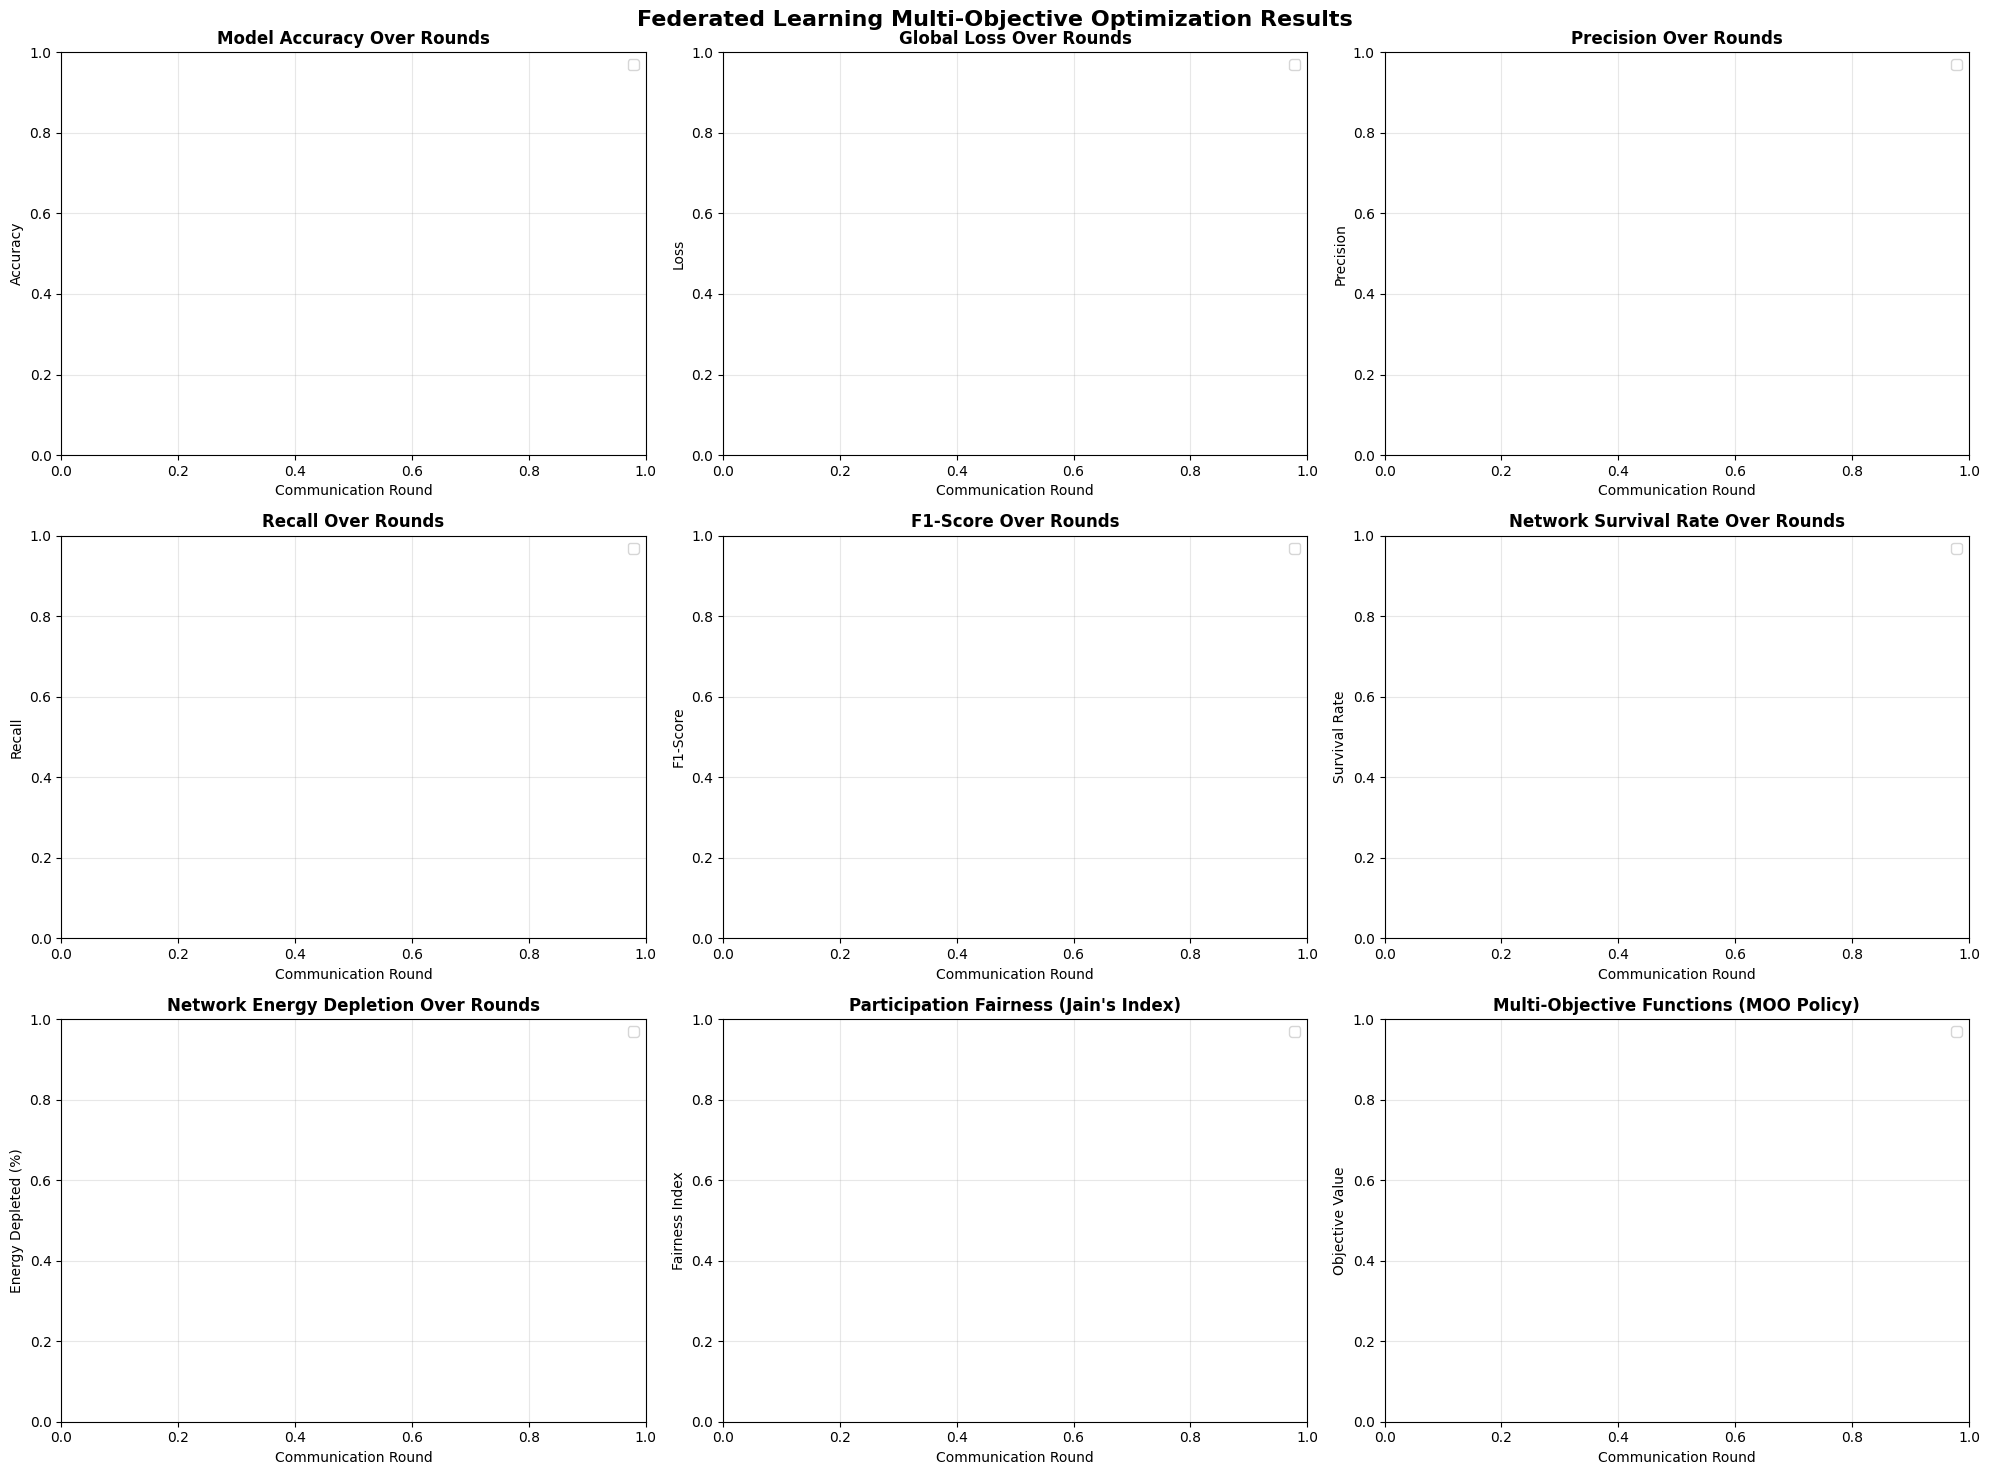


Generating network lifetime analysis...


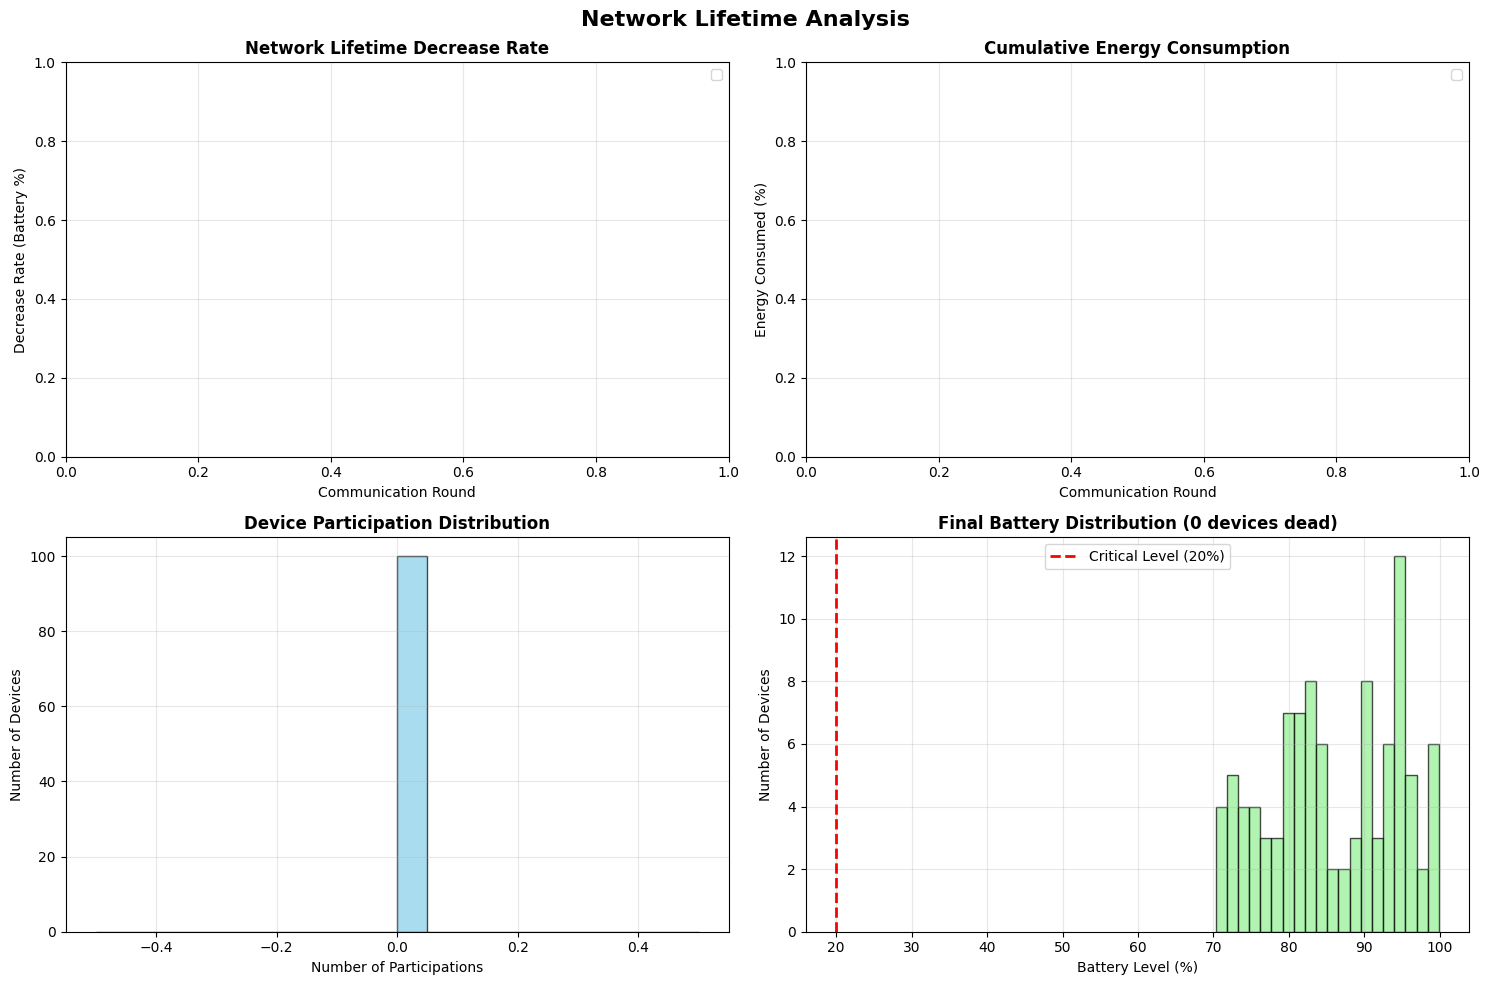


FEDERATED LEARNING SIMULATION SUMMARY
Configuration:
- Number of clients: 100
- Rounds per scenario: 50
- Clients per round: 10
- Dataset: FashionMNIST

Final Network State:
- Active devices: 100/100
- Dead devices: 0
- Average battery level: 85.9%
- Total participations: 0

ADDITIONAL ANALYSIS

1. Analyzing objective function convergence...
No objective data available

2. Analyzing adaptive weight evolution...
Weight adaptation history not available

3. Comparing with existing methods...


ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (2,) and arg 1 with shape (5,).

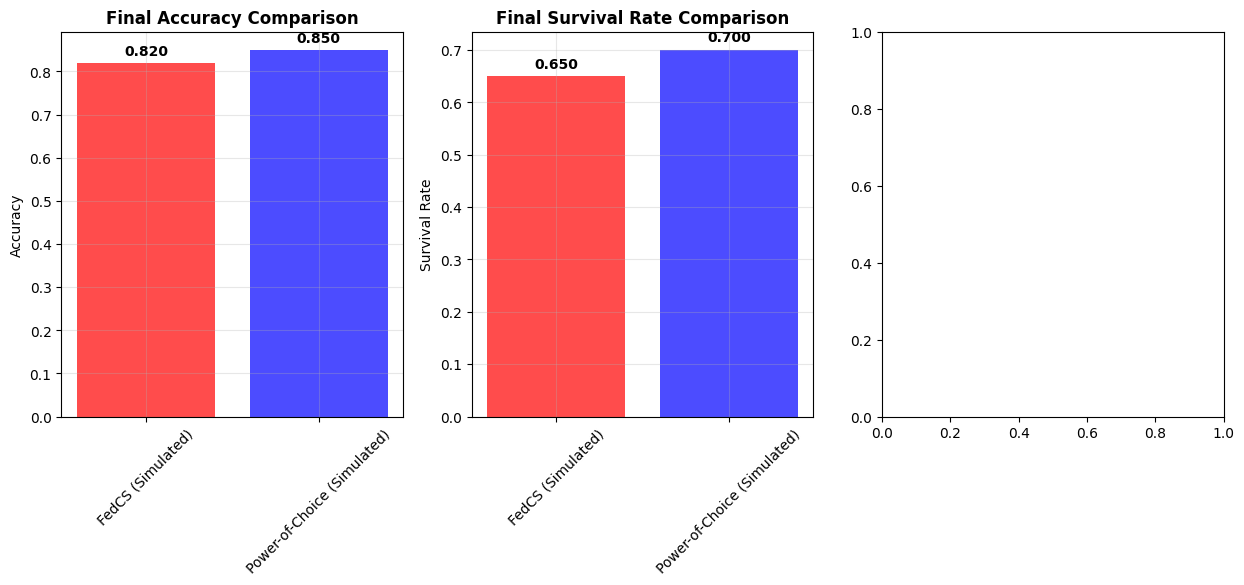

In [14]:
print("Starting Federated Learning Multi-Objective Optimization Simulation")
print("="*70)

# Run comprehensive simulation
simulator, results, data_df, comparison_df = run_comprehensive_simulation()

if simulator is not None:
    print("\n" + "="*50)
    print("ADDITIONAL ANALYSIS")
    print("="*50)
    
    # Analyze objective convergence
    print("\n1. Analyzing objective function convergence...")
    analyze_objective_convergence(simulator)
    
    # Analyze weight adaptation
    print("\n2. Analyzing adaptive weight evolution...")
    analyze_weight_adaptation(simulator)
    
    # Compare with existing methods
    print("\n3. Comparing with existing methods...")
    compare_with_existing_methods(simulator)
    
    # Generate LaTeX tables
    if data_df is not None:
        generate_latex_tables(simulator, data_df)
    
    print("\n" + "="*70)
    print("SIMULATION COMPLETED SUCCESSFULLY!")
    print("="*70)
    
    # Final summary statistics
    print(f"\nFinal Network Statistics:")
    active_devices = len([d for d in simulator.devices if d.is_active])
    print(f"- Devices still active: {active_devices}/{simulator.num_clients}")
    print(f"- Network survival rate: {active_devices/simulator.num_clients:.2%}")
    
    if 'multi_objective' in simulator.results:
        moo_results = simulator.results['multi_objective']
        if moo_results['accuracy']:
            print(f"- Multi-objective final accuracy: {moo_results['accuracy'][-1]:.4f}")
            print(f"- Multi-objective peak accuracy: {max(moo_results['accuracy']):.4f}")
    
else:
    print("Simulation failed. Please check the error messages above.")


In [ ]:
def run_custom_simulation(num_clients=50, num_rounds=30, alpha=0.3):
    """Run simulation with custom parameters"""
    
    simulator = FederatedLearningSimulator(
        num_clients=num_clients,
        num_rounds=num_rounds,
        clients_per_round=max(5, num_clients//10)
    )
    
    # Initialize with specific non-IID level
    simulator.initialize_devices(alpha=alpha)
    
    # Run multi-objective scenario only
    results = simulator.run_scenario("multi_objective")
    
    # Quick visualization
    if results['accuracy']:
        plt.figure(figsize=(12, 4))
        
        plt.subplot(1, 3, 1)
        plt.plot(results['accuracy'], 'g-', linewidth=2)
        plt.title('Accuracy Over Rounds')
        plt.xlabel('Round')
        plt.ylabel('Accuracy')
        plt.grid(True, alpha=0.3)
        
        plt.subplot(1, 3, 2)
        plt.plot(results['survival_rate'], 'b-', linewidth=2)
        plt.title('Network Survival Rate')
        plt.xlabel('Round')
        plt.ylabel('Survival Rate')
        plt.grid(True, alpha=0.3)
        
        plt.subplot(1, 3, 3)
        plt.plot(results['energy_consumed'], 'r-', linewidth=2)
        plt.title('Energy Consumption')
        plt.xlabel('Round')
        plt.ylabel('Energy Depleted (%)')
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    return simulator

# Test with different configurations
def test_different_configurations():
    """Test the simulation with different parameter configurations"""
    
    configs = [
        {"num_clients": 30, "num_rounds": 20, "alpha": 0.1},  # Highly non-IID
        {"num_clients": 50, "num_rounds": 30, "alpha": 0.5},  # Moderately non-IID
        {"num_clients": 100, "num_rounds": 50, "alpha": 1.0}   # Nearly IID
    ]
    
    results_summary = []
    
    for i, config in enumerate(configs):
        print(f"\nTesting Configuration {i+1}: {config}")
        simulator = run_custom_simulation(**config)
        
        if 'multi_objective' in simulator.results:
            results = simulator.results['multi_objective']
            summary = {
                'config': config,
                'final_accuracy': results['accuracy'][-1] if results['accuracy'] else 0,
                'final_survival': results['survival_rate'][-1] if results['survival_rate'] else 0,
                'rounds_completed': len(results['accuracy']) if results['accuracy'] else 0
            }
            results_summary.append(summary)
    
    # Print comparison
    print(f"\n{'='*60}")
    print("CONFIGURATION COMPARISON")
    print(f"{'='*60}")
    
    for i, summary in enumerate(results_summary):
        config = summary['config']
        print(f"\nConfiguration {i+1} (α={config['alpha']}):")
        print(f"  Final Accuracy: {summary['final_accuracy']:.4f}")
        print(f"  Final Survival: {summary['final_survival']:.4f}")
        print(f"  Rounds Completed: {summary['rounds_completed']}")

print("Federated Learning Multi-Objective Optimization Simulator Ready!")
print("Run the main simulation with: run_comprehensive_simulation()")
print("Test different configurations with: test_different_configurations()")
print("Run custom simulation with: run_custom_simulation(num_clients=50, num_rounds=30)")
        